In [3]:
#Library import

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime


In [4]:
dataset = pd.read_csv('transactions.csv')
dataset.columns = dataset.columns.str.strip()
# dataset = dataset.drop(['transaction_id',], axis=1)
df = dataset.copy()
df.head()

,transaction_id,user_id,transaction_amount,transaction_date,merchant_id,merchant_name,merchant_category_id,geo_location,payment_method,user_agent,loyalty_program,discount_applied,promo_amount,transaction_notes,merchant_rating,transaction_status,is_refunded
0,4a71b7d1-34fa-45cf-b40a-a730d16ce617,U10578,23500.0,2024-05-09,M04936,Cox Inc,5732,"-7.974781, 112.633863",balance,Android 9,no,no,0.0,no,5,completed,no
1,b29665c0-8373-4ec1-a121-a041c77ffb51,U08353,150500.0,2024-05-30,M06359,"King, Rice and Ramirez",5812,"-6.188155, 106.817086",balance,iPhone; CPU iPhone OS 3_1_3 like Mac OS X,no,no,0.0,yes,2,completed,no
2,3e32187b-b374-4f1b-a64e-b1ebcc856563,U04564,65800.0,2024-03-08,M01710,"Lyons, Porter and Williams",5812,"-7.962043, 112.637274",credit_card,Android 2.0.1,no,no,0.0,no,3,completed,no
3,df8ad42e-aaf6-46d2-8d8f-1e291a4554bd,U22797,45600.0,2024-05-14,M02852,Smith Ltd,5411,"-6.592793, 106.806543",balance,iPad; CPU iPad OS 9_3_5 like Mac OS X,no,no,0.0,no,3,completed,no
4,334468df-4d71-4e4a-935c-32c17c306611,U18053,8500.0,2024-04-09,M00722,Bush Group,5411,"-6.269386, 106.979043",balance,Android 2.0.1,yes,no,0.0,no,4,completed,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 278932 entries, 0 to 278931
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   transaction_id        278932 non-null  str    
 1   user_id               278932 non-null  str    
 2   transaction_amount    278932 non-null  float64
 3   transaction_date      278932 non-null  str    
 4   merchant_id           278932 non-null  str    
 5   merchant_name         278932 non-null  str    
 6   merchant_category_id  278932 non-null  int64  
 7   geo_location          278932 non-null  str    
 8   payment_method        278932 non-null  str    
 9   user_agent            278932 non-null  str    
 10  loyalty_program       278932 non-null  str    
 11  discount_applied      278932 non-null  str    
 12  promo_amount          278932 non-null  float64
 13  transaction_notes     278932 non-null  str    
 14  merchant_rating       278932 non-null  int64  
 15  transaction

In [4]:
df.describe(include='all')

,transaction_id,user_id,transaction_amount,transaction_date,merchant_id,merchant_name,merchant_category_id,geo_location,payment_method,user_agent,loyalty_program,discount_applied,promo_amount,transaction_notes,merchant_rating,transaction_status,is_refunded
count,278932,278932,278932.000000,278932,278932,278932,278932.000000,278932,278932,278932,278932,278932,278932.000000,278932,278932.00000,278932,278932
unique,278932,24321,NaN,92,6489,5820,NaN,278916,2,136,2,2,NaN,2,NaN,2,2
top,4a71b7d1-34fa-45cf-b40a-a730d16ce617,U07052,NaN,2024-04-07,M02610,Johnson Group,NaN,"-6.981828, 110.406825",balance,Android 3.2.1,no,no,NaN,no,NaN,completed,no
freq,1,27,NaN,6854,70,657,NaN,2,222978,3214,211974,231340,NaN,214887,NaN,264907,264821
mean,NaN,NaN,50098.301378,NaN,NaN,NaN,5806.529964,NaN,NaN,NaN,NaN,NaN,4311.858087,NaN,3.80046,NaN,NaN
std,NaN,NaN,50021.138491,NaN,NaN,NaN,509.152141,NaN,NaN,NaN,NaN,NaN,16527.140346,NaN,1.16671,NaN,NaN
min,NaN,NaN,1000.000000,NaN,NaN,NaN,4722.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,1.00000,NaN,NaN
25%,NaN,NaN,14400.000000,NaN,NaN,NaN,5541.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,3.00000,NaN,NaN
50%,NaN,NaN,34800.000000,NaN,NaN,NaN,5812.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,4.00000,NaN,NaN
75%,NaN,NaN,69400.000000,NaN,NaN,NaN,5912.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,5.00000,NaN,NaN


In [5]:
df.isnull().sum()

transaction_id          0
user_id                 0
transaction_amount      0
transaction_date        0
merchant_id             0
merchant_name           0
merchant_category_id    0
geo_location            0
payment_method          0
user_agent              0
loyalty_program         0
discount_applied        0
promo_amount            0
transaction_notes       0
merchant_rating         0
transaction_status      0
is_refunded             0
dtype: int64

In [6]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

Skipping transaction_id as it has more than 20 unique values.
Skipping user_id as it has more than 20 unique values.
Skipping transaction_date as it has more than 20 unique values.
Skipping merchant_id as it has more than 20 unique values.
Skipping merchant_name as it has more than 20 unique values.
Skipping geo_location as it has more than 20 unique values.


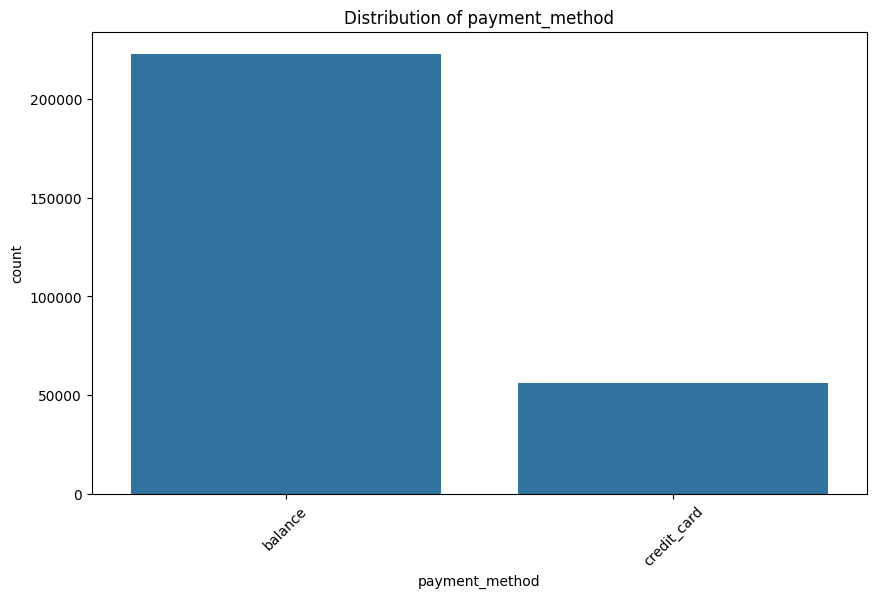

Skipping user_agent as it has more than 20 unique values.


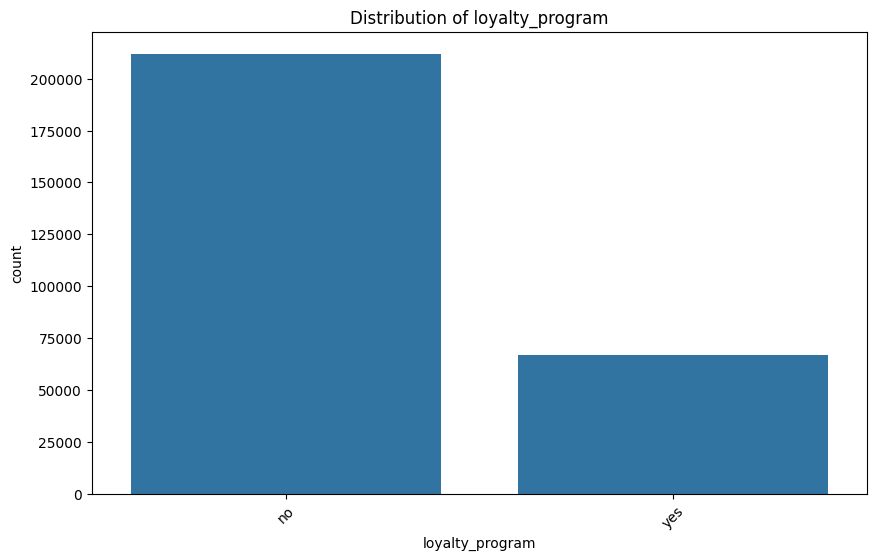

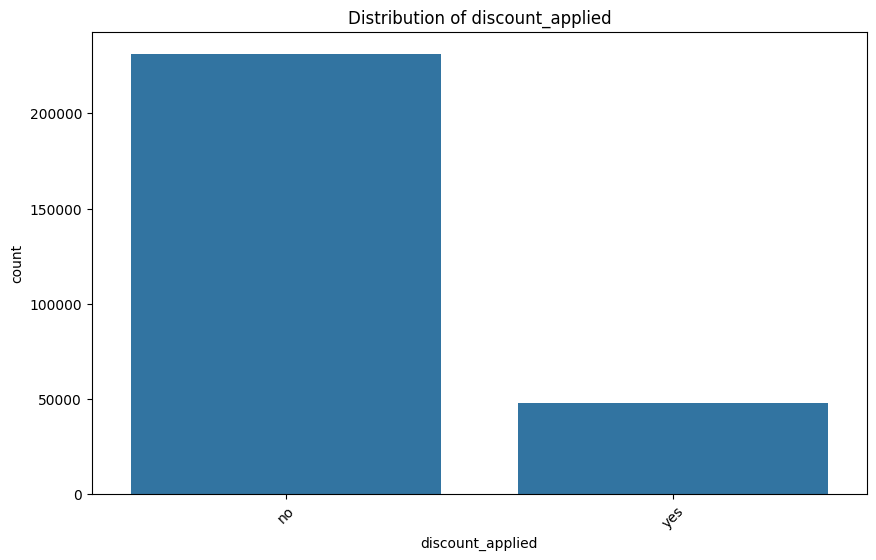

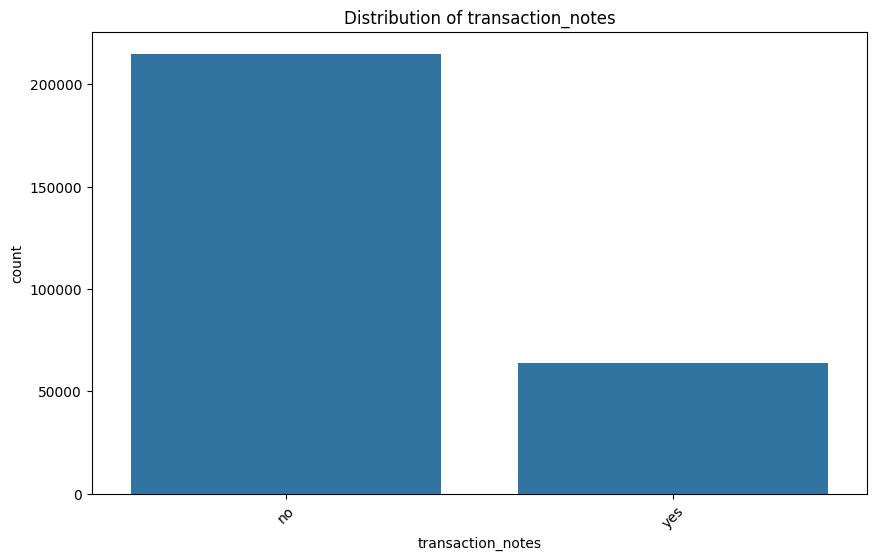

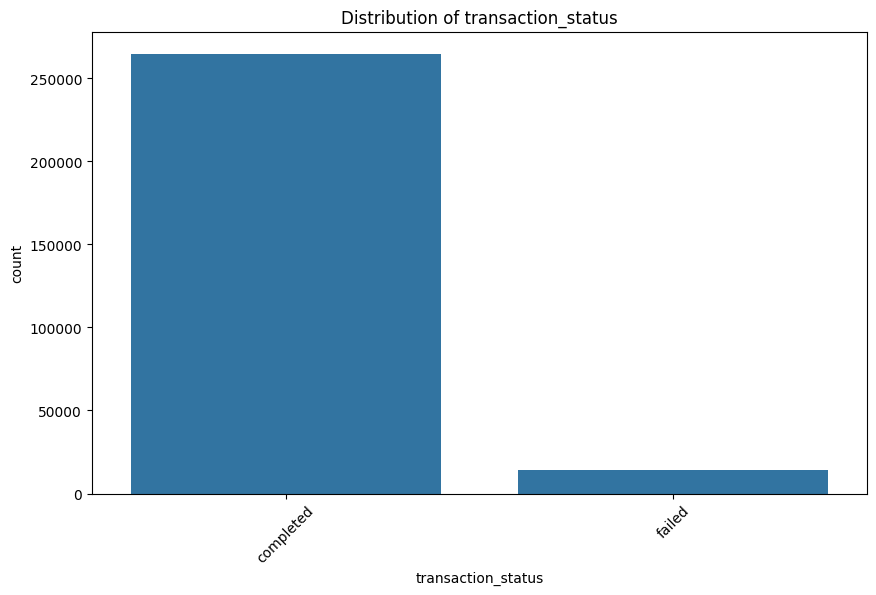

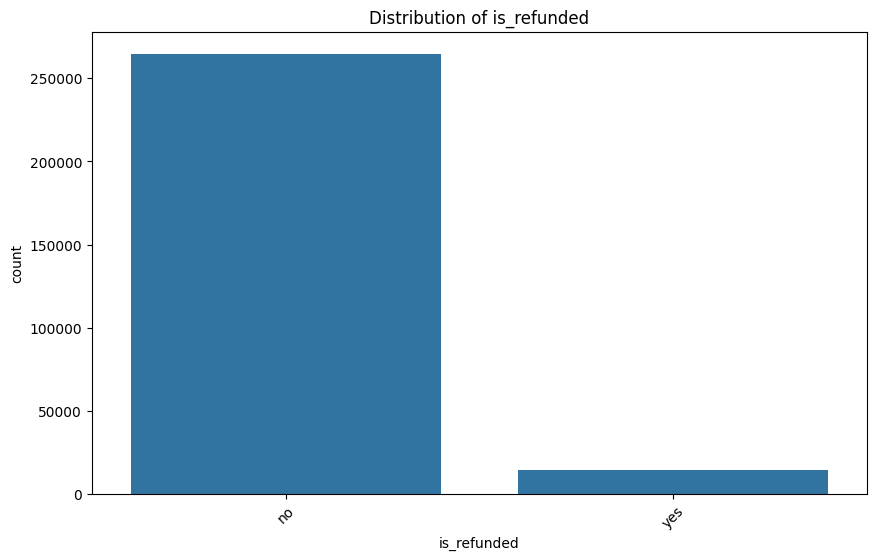

In [7]:
def plot_categorical_distribution(df, column):
    if df[column].nunique() > 20:
        print(f"Skipping {column} as it has more than 20 unique values.")
        return
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=column)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()

for col in categorical_cols:
    plot_categorical_distribution(df, col)

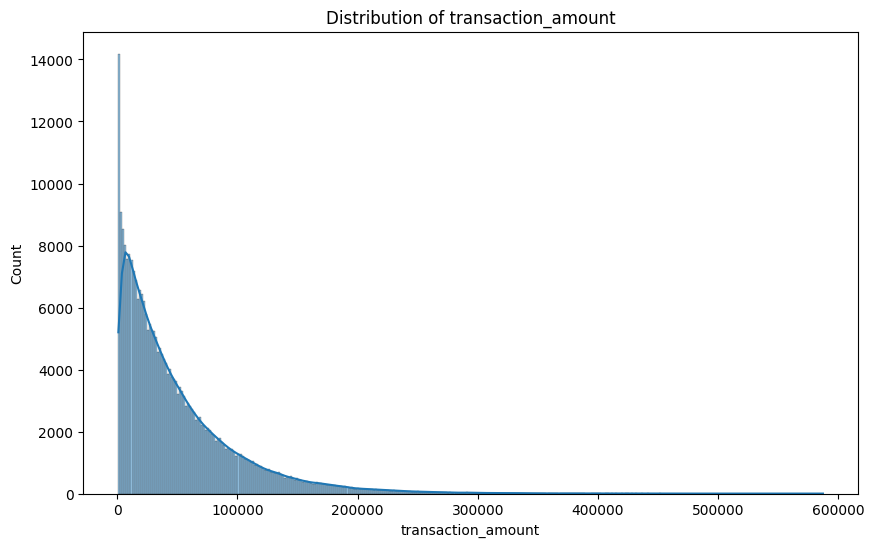

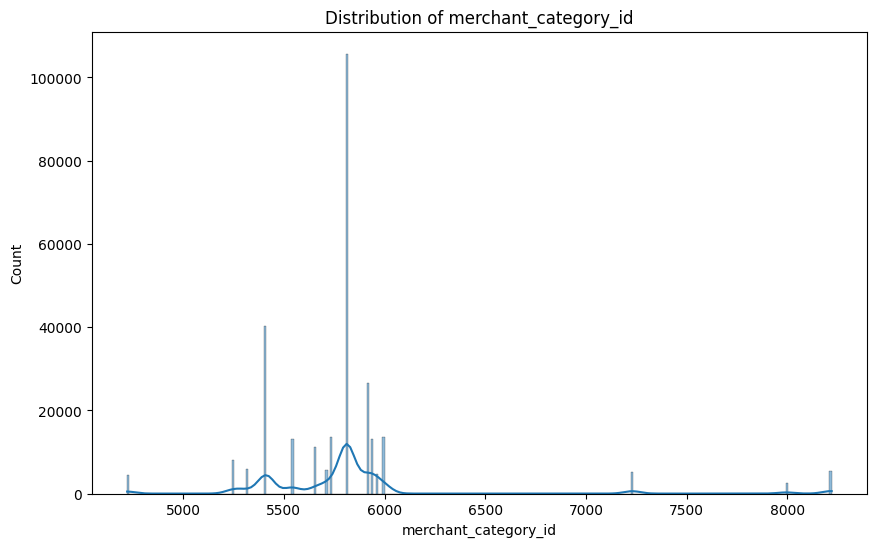

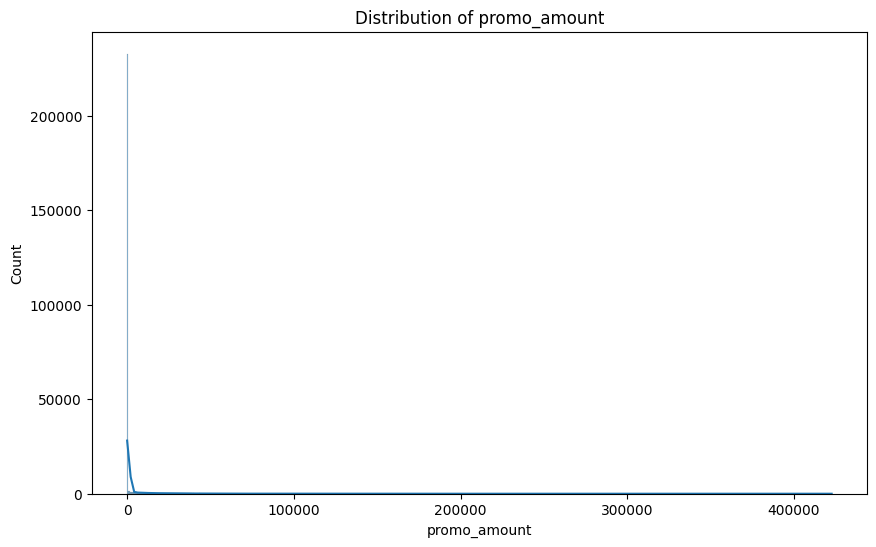

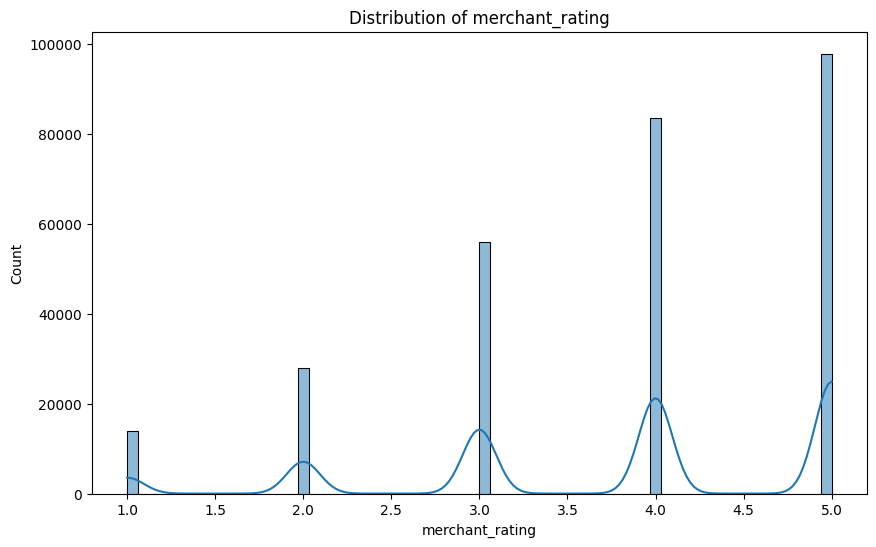

In [8]:
def plot_distribution(df, column):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

for col in numerical_cols:
    plot_distribution(df, col)

In [9]:
#RFM Analysis
snapshot_date = df['transaction_date'].max()
snapshot_date = datetime.strptime(snapshot_date, '%Y-%m-%d')

rfm_df = df.groupby('user_id').agg(
    recency=('transaction_date', lambda x: (snapshot_date - pd.to_datetime(x).max()).days),
    frequency=('transaction_id', 'count'),
    monetary_value=('transaction_amount', 'sum')
).reset_index()

rfm_df.head()

,user_id,recency,frequency,monetary_value
0,U00001,19,11,514600.0
1,U00002,41,10,364500.0
2,U00003,10,11,1007900.0
3,U00004,19,9,430800.0
4,U00005,33,10,795200.0


In [10]:
#Behavioral Features
user_features = df.groupby('user_id').agg(
    average_transaction_amount=('transaction_amount', 'mean'),
    total_transaction_amount=('transaction_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    unique_categories=('merchant_category_id', 'nunique'),
    favorite_category=('merchant_category_id', lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    preferred_payment_method=('payment_method', lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    # return_rate=('is_refunded', 'mean')
).reset_index()

user_features.head()

,user_id,average_transaction_amount,total_transaction_amount,transaction_count,unique_categories,favorite_category,preferred_payment_method
0,U00001,46781.818182,514600.0,11,9,5712,balance
1,U00002,36450.000000,364500.0,10,5,5812,balance
2,U00003,91627.272727,1007900.0,11,7,5812,balance
3,U00004,47866.666667,430800.0,9,7,5812,balance
4,U00005,79520.000000,795200.0,10,9,5311,balance


In [11]:
#time Based Features
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['month'] = df['transaction_date'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

time_features = df.groupby('user_id').agg(  
    avg_day_of_week=('day_of_week', 'mean'),
    avg_month=('month', 'mean'),
    weekend_transaction_ratio=('is_weekend', 'mean')
).reset_index()

time_features.head()


,user_id,avg_day_of_week,avg_month,weekend_transaction_ratio
0,U00001,2.636364,3.909091,0.272727
1,U00002,3.800000,3.700000,0.400000
2,U00003,2.636364,4.181818,0.272727
3,U00004,4.222222,3.888889,0.666667
4,U00005,3.100000,3.400000,0.400000


In [12]:
#basket/purchase pattern features

basket = df.groupby(['user_id', 'transaction_id']).agg(
    basket_value=('transaction_amount', 'sum'),
    basket_size=('merchant_category_id', 'nunique')
).reset_index()

user_basket_features = basket.groupby('user_id').agg(
    avg_basket_value=('basket_value', 'mean'),
    avg_basket_size=('basket_size', 'mean'),
    max_basket_value=('basket_value', 'max'),
).reset_index()     

array([[<Axes: title={'center': 'recency'}>,
        <Axes: title={'center': 'frequency'}>],
       [<Axes: title={'center': 'monetary_value'}>, <Axes: >]],
      dtype=object)

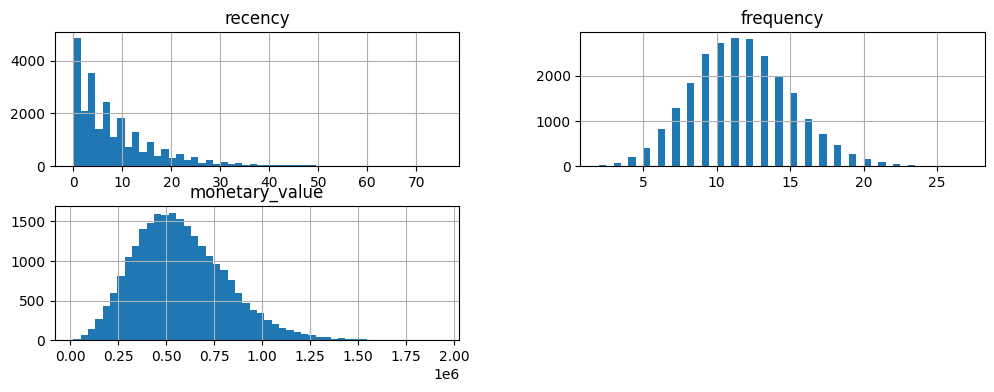

In [13]:
rfm_df[['recency','frequency','monetary_value']].hist(bins=50, figsize=(12,4))

<Axes: >

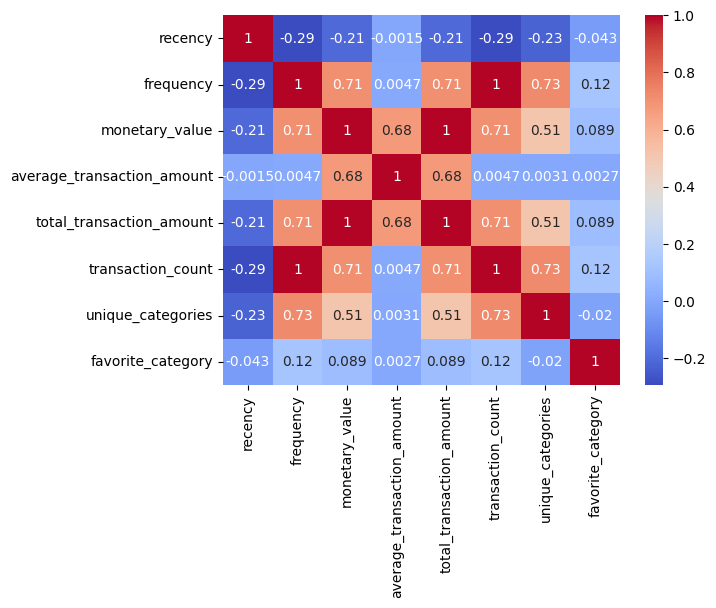

In [14]:
combined = rfm_df.merge(user_features, on='user_id')
sns.heatmap(combined.select_dtypes('number').corr(), annot=True, cmap='coolwarm')

In [15]:
#gender definition

for i in df.columns:
    print(i)


transaction_id
user_id
transaction_amount
transaction_date
merchant_id
merchant_name
merchant_category_id
geo_location
payment_method
user_agent
loyalty_program
discount_applied
promo_amount
transaction_notes
merchant_rating
transaction_status
is_refunded
day_of_week
month
is_weekend


In [ ]:
#Predict gender
df_gender = df.copy()


MCC_RANGES = [
    (1,    1499, "Agricultural Services"),
    (1500, 2999, "Contracted Services"),
    (3000, 3999, "Travel & Airlines"),
    (4000, 4799, "Transportation Services"),
    (4800, 4999, "Utility Services"),
    (5000, 5599, "Retail Outlet Services"),
    (5600, 5699, "Clothing Stores"),
    (5700, 7299, "Miscellaneous Stores"),
    (7300, 7999, "Business Services"),
    (8000, 8999, "Professional Services"),
    (9000, 9999, "Government Services"),
]

def get_merchant_category(merchant_category_id):
    for lower, upper, category in MCC_RANGES:
        if lower <= merchant_category_id <= upper:
            return category
    return "Unknown Category"

merchant_category = df[['merchant_id', 'merchant_name', 'merchant_category_id']]

merchant_category['merchant_id'] = merchant_category['merchant_id'].astype(str).str[1:]
merchant_category['merchant_category'] = merchant_category['merchant_id'].apply(get_merchant_category)

merchant_category.head()

,merchant_id,merchant_name,merchant_category_id,merchant_category
0,04936,Cox Inc,5732,Miscellaneous Stores
1,06359,"King, Rice and Ramirez",5812,Miscellaneous Stores
2,01710,"Lyons, Porter and Williams",5812,Miscellaneous Stores
3,02852,Smith Ltd,5411,Retail Outlet Services
4,00722,Bush Group,5411,Retail Outlet Services
